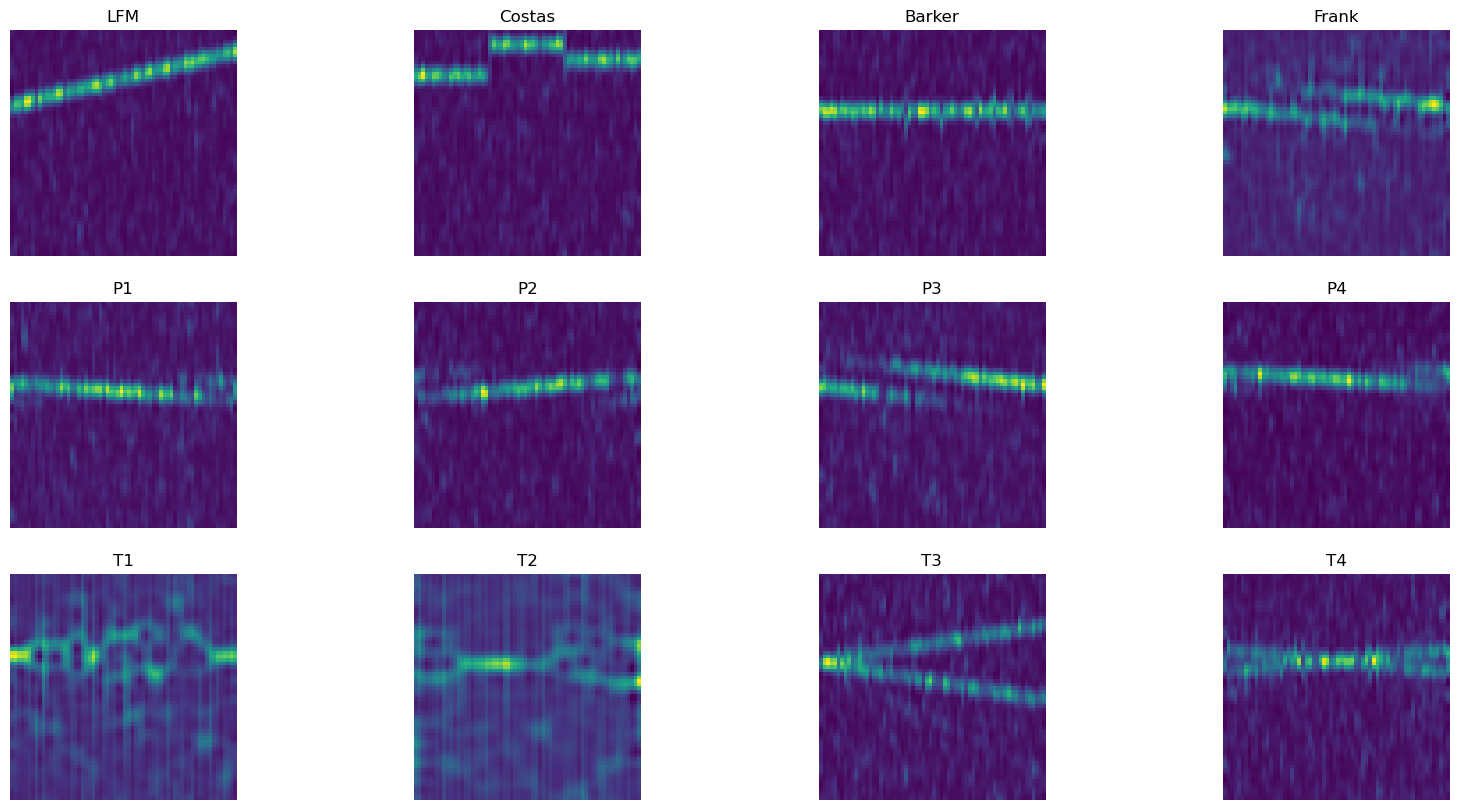

In [1]:
import os
import random

path = '/data/kiwan/Unknown_radar_detection/Adaptive_wavelet_transform/240523_CWD-v1/'
import matplotlib.pyplot as plt

# 클래스 목록
classes = ['LFM', 'Costas', 'Barker', 'Frank', 'P1', 'P2', 'P3', 'P4', 'T1', 'T2', 'T3', 'T4']

row_imgs = []
for cls in classes:
    cls_dir = os.path.join(path, cls)
    image_paths = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.endswith('.png') and 'snr-0' in f]
    if image_paths:
        row_imgs.append(random.choice(image_paths))

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
for i, img_path in enumerate(row_imgs):
    ax = axes[i//4, i%4]
    ax.imshow(plt.imread(img_path))
    ax.axis('off')
    ax.set_title(img_path.split('/')[-2])

KeyboardInterrupt: 

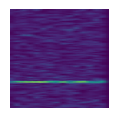

In [3]:
import os
import numpy as np
import random
from _generator_utils import *

# output_dir = '/data/kiwan/LPI_KIWAN/'
output_dir = 'lpi_testsssssss'
os.makedirs(output_dir, exist_ok=True)


fs = 100e6
A = 1
fps = 128
snr_values = np.arange(-16, 2, 2)
waveforms = ['Barker', 'Costas', 'Frank', 'LFM', 'P1', 'P2', 'P3', 'P4', 'T1', 'T2', 'T3', 'T4']
onlystft = True

Nmin, Nmax = 800, 1500  # Adjusted range for sequence length
fc_low, fc_high = fs / 8, fs / 7  # Adjusted frequency range
B_low, B_high = fs / 25, fs / 20  # Adjusted bandwidth range

for waveform in waveforms:
    os.makedirs(os.path.join(output_dir, waveform), exist_ok=True)

for waveform_idx, waveform in enumerate(waveforms):
    for snr_idx, snr in enumerate(snr_values):

        print(f'Generating {waveform} waveform with SNR = {snr} dB....', end='\r')

        if waveform == 'LFM':
            sweep = ['Up', 'Down']
            fc = np.linspace(fc_low, fc_high, fps)
            fc = fc[np.random.permutation(fps)]
            B = np.linspace(B_low, B_high, fps)
            B = B[np.random.permutation(fps)]
            N = np.linspace(Nmin, Nmax, fps)
            N = np.round(N[np.random.permutation(fps)])

            for fps_idx in range(fps):
                wav = type_lfm(N[fps_idx], fs, A, fc[fps_idx], B[fps_idx], random.choice(sweep))
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)

        elif waveform == 'Costas':
            fc = np.linspace(fc_low / 4, fc_high / 4, fps)
            fc = fc[np.random.permutation(fps)]
            N = np.linspace(Nmin, Nmax, fps)
            N = np.round(N[np.random.permutation(fps)]).astype(int)
            Lc = np.random.choice([4, 6, 8])  # Adjusted code length

            for fps_idx in range(fps):
                wav = type_costas(N[fps_idx], fs, A, fc[fps_idx], Lc)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)

        elif waveform == 'Barker':
            fc = np.linspace(fc_low, fc_high, fps)
            fc = fc[np.random.permutation(fps)]
            barker_codes = {
                7: np.array([1, 1, 1, -1, -1, 1, -1]),
                11: np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1]),
                13: np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1])
            }
            Bar = np.random.choice([7, 11, 13])
            Ncc = np.random.choice([20, 22, 24])  # Adjusted repeat count
            code = barker_codes[Bar]

            for fps_idx in range(fps):
                wav = type_barker(Ncc, fs, A, fc[fps_idx], code)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)

        elif waveform == 'Frank':
            fc = np.linspace(fc_low, fc_high, fps)
            fc = fc[np.random.permutation(fps)]
            cpp = np.random.choice([4, 6, 8])  # Adjusted code phase pattern
            M = np.random.choice([10, 12, 14])  # Adjusted frequency steps

            for fps_idx in range(fps):
                wav = type_frank(cpp, fs, A, fc[fps_idx], M)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)

        elif waveform in ['P1', 'P2', 'P3', 'P4']:
            fc = np.linspace(fc_low, fc_high, fps)
            fc = fc[np.random.permutation(fps)]
            cpp = np.random.choice([4, 6, 8])
            M_or_p = np.random.choice([10, 12, 14]) if waveform in ['P1', 'P2'] else np.random.choice([36, 49, 64])

            for fps_idx in range(fps):
                if waveform == 'P1':
                    wav = type_P1(cpp, fs, A, fc[fps_idx], M_or_p)
                elif waveform == 'P2':
                    wav = type_P2(cpp, fs, A, fc[fps_idx], M_or_p)
                elif waveform == 'P3':
                    wav = type_P3(cpp, fs, A, fc[fps_idx], M_or_p)
                elif waveform == 'P4':
                    wav = type_P4(cpp, fs, A, fc[fps_idx], M_or_p)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)

        elif waveform in ['T1', 'T2', 'T3', 'T4']:
            fc = np.linspace(fc_low / 2, fc_high / 2, fps)
            fc = fc[np.random.permutation(fps)]
            Nps = 3  # Fixed pattern length
            Ng = np.random.choice([5, 7, 9])  # Adjusted group count
            B = np.linspace(B_low, B_high, fps)  # Adjusted bandwidth range
            N = np.linspace(Nmin, Nmax, fps)
            N = np.round(N[np.random.permutation(fps)]).astype(int)

            for fps_idx in range(fps):
                if waveform == 'T1':
                    wav = type_T1(fs, A, fc[fps_idx], Nps, Ng)
                elif waveform == 'T2':
                    wav = type_T2(fs, A, fc[fps_idx], Nps, Ng)
                elif waveform == 'T3':
                    wav = type_T3(N[fps_idx], fs, A, fc[fps_idx], Nps, B[fps_idx])
                elif waveform == 'T4':
                    wav = type_T4(N[fps_idx], fs, A, fc[fps_idx], Nps, B[fps_idx])
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)


In [ ]:
import os
import numpy as np
import random
from _generator_utils import *

# output_dir = '/data/kiwan/LPI_KIWAN/'
output_dir = 'lpi_testset/'
os.makedirs(output_dir, exist_ok=True)
    
fs = 1e6
A = 1
fps = 128
snr_values =  np.arange(-16, 2, 2) # np.arange(2, 10, 2)
waveforms = ['Barker', 'Costas', 'Frank','LFM', 'P1', 'P2', 'P3', 'P4', 'T1', 'T2', 'T3', 'T4']
onlystft = False
for waveform in waveforms:
    os.makedirs(os.path.join(output_dir, waveform), exist_ok=True)

for waveform_idx, waveform in enumerate(waveforms):
    for snr_idx, snr in enumerate(snr_values := snr_values):

        print(f'Generating {waveform} waveform with SNR = {snr} dB....', end='\r')

        Nmin, Nmax = 1024, 1920
        
        if waveform == 'LFM':
            sweep = ['Up', 'Down']
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]

            B = np.linspace(fs/20, fs/16, fps)
            B = B[np.random.permutation(fps)]

            N = np.linspace(Nmin, Nmax, fps)
            N = np.round(N[np.random.permutation(fps)])
            
            for fps_idx in range(fps):
                wav = type_lfm(N[fps_idx], fs, A, fc[fps_idx], B[fps_idx], random.choice(sweep))
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)
                        
        elif waveform == 'Costas':
            fc = np.linspace(fs/30, fs/24, fps)
            fc = fc[np.random.permutation(fps)]
            N = np.linspace(Nmin, Nmax, fps)
            N = np.round(N[np.random.permutation(fps)]).astype(int) # [0] : 
            
            Lc = np.random.choice([3, 4, 5, 6])
            
            for fps_idx in range(fps):
                wav = type_costas(N[fps_idx], fs, A, fc[fps_idx], Lc)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)
            
        elif waveform == 'Barker':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            barker_codes = {
                7: np.array([1, 1, 1, -1, -1, 1, -1]),
                11: np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1]),
                13: np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1])}
            
            Ncc = np.random.choice([20, 21, 22, 23, 24])
            Bar = np.random.choice([7, 11, 13])
            
            code = barker_codes[Bar]
            
            for fps_idx in range(fps):
                wav = type_barker(Ncc, fs, A, fc[fps_idx], code)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)
                
        elif waveform == 'Frank':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            cpp = np.random.choice([3, 4, 5])
            M = np.random.choice([6, 7, 8])            
            
            for fps_idx in range(fps):
                wav = type_frank(cpp, fs, A, fc[fps_idx], M)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)
        elif waveform == 'P1':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            cpp = np.random.choice([3, 4, 5])
            M = np.random.choice([6, 7, 8])
            
            for fps_idx in range(fps):            
                wav = type_P1(cpp, fs, A, fc[fps_idx], M)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)
        elif waveform == 'P2':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            cpp = np.random.choice([3, 4, 5])
            M = np.random.choice([6, 8])            
            
            for fps_idx in range(fps):
                wav = type_P2(cpp, fs, A, fc[fps_idx], M)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)
        elif waveform == 'P3':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            cpp = np.random.choice([3, 4, 5])
            p = np.random.choice([36, 49, 64])
            
            for fps_idx in range(fps):
                wav = type_P3(cpp, fs, A, fc[fps_idx], p)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)

        elif waveform == 'P4':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            cpp = np.random.choice([3, 4, 5])
            p = np.random.choice([36, 49, 64])
            
            for fps_idx in range(fps):
                wav = type_P4(cpp, fs, A, fc[fps_idx], p)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)
        elif waveform == 'T1':
            fc = np.linspace(fs/16, fs/8, fps)  # 16, 8하면 이쁘게 나옴
            fc = fc[np.random.permutation(fps)]
            
            Nps = 2
            Ng = np.random.choice([4,5,6])
            
            for fps_idx in range(fps):
                wav = type_T1(fs, A, fc[fps_idx], Nps, Ng)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)
        elif waveform == 'T2':
            fc = np.linspace(fs/16, fs/8, fps)  # 16, 8하면 이쁘게 나옴
            fc = fc[np.random.permutation(fps)]
            
            Nps = 2
            Ng = np.random.choice([4,5,6])
            
            for fps_idx in range(fps):
                wav = type_T2(fs, A, fc[fps_idx], Nps, Ng)
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)
        elif waveform == 'T3':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            B = np.linspace(fs/20, fs/10, fps)
            B = B[np.random.permutation(fps)]
            
            Nps = 2
            Ng = np.random.choice([4,5,6])
            N = np.linspace(Nmin, Nmax, fps)
            N = np.round(N[np.random.permutation(fps)]).astype(int)
            
            for fps_idx in range(fps):
                wav = type_T3(N[fps_idx], fs, A, fc[fps_idx], Nps, B[fps_idx])
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)
        elif waveform == 'T4':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            B = np.linspace(fs/20, fs/10, fps)
            B = B[np.random.permutation(fps)]
            
            Nps = 2
            Ng = np.random.choice([4,5,6])
            N = np.linspace(Nmin, Nmax, fps)
            N = np.round(N[np.random.permutation(fps)]).astype(int)
            
            for fps_idx in range(fps):
                wav = type_T4(N[fps_idx], fs, A, fc[fps_idx], Nps, B[fps_idx])
                deployment(wav, snr, waveform, fps_idx, output_dir, only_stft=onlystft)
            
    
# import matplotlib.pyplot as plt
# from scipy.signal import stft
# datatypes = ['Signal', 'Noise', 'Noisy', 'pwnNoisy']


# fig, axes = plt.subplots(len(waveforms), len(snr_values), figsize=(20, 40))
# plt.subplots_adjust(top=1, wspace=0.05, hspace=0.05)

# idx = 0
# for i, waveform in enumerate(waveforms):
#     for j, snr in enumerate(snr_values):
#         ax = axes[i, j]
#         noisy_signal = np.load(os.path.join(output_dir, waveform, f'{waveform}_snr{snr}_{datatypes[-1]}_{idx}.npy'))
#         f, t, Zxx = stft(noisy_signal, fs, nperseg=256)
#         ax.pcolormesh(t, f[:len(f)//2], np.abs(Zxx[:len(f)//2]), shading='gouraud')
        
#         ax.axis('off')
#         ax.set_title(f'{waveform} (SNR = {snr} dB)')

   

In [ ]:
import os
import numpy as np
import random
from matplotlib import pyplot as plt
from _generator_utils import *
from scipy.signal import stft

import numpy as np


def fps_wav(wav, snr):    
    delays = np.random.choice(delayset, 5, replace=False)
    gains = np.random.choice(attenuationset, 5, replace=False)
    signal = multipath_channel(wav, fs, delays, gains)
    noisy_signal = add_awgn(signal, snr)

    waveform_folder = os.path.join(output_folder, waveform)
    np.save(os.path.join(waveform_folder, f'{waveform}_snr{snr}_signal.npy'), wav)
    np.save(os.path.join(waveform_folder, f'{waveform}_snr{snr}_cwd_signal.npy'), signal)
    np.save(os.path.join(waveform_folder, f'{waveform}_snr{snr}_noisy_signal.npy'), noisy_signal)


fs = 100e6
A = 1 
fps = 1
waveforms = ['LFM', 'Costas', 'Barker', 'Frank', 'P1', 'P2', 'P3', 'P4', 'T1', 'T2', 'T3', 'T4']
output_folder = 'lpi_dataset'
os.makedirs(output_folder, exist_ok=True)

for waveform in waveforms:
    os.makedirs(os.path.join(output_folder, waveform), exist_ok=True)
    
attenuationset = np.arange(-20, 2, 2)
delayset = np.arange(1, 1001, 50) * 1e-9
snr_values = np.arange(2, 10, 2)

target_signal = 'Barker'
fig, axes = plt.subplots(len(waveforms)*3, len(snr_values), figsize=(20, 50))
# fig.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.05, hspace=0.05) 
for waveform_idx, waveform in enumerate(waveforms):
    # if waveform != target_signal:
    #     continue
    for snr_idx, snr in enumerate(snr_values):

        print(f'Generating {waveform} waveform with SNR = {snr} dB...', end='\r')

        Nmin, Nmax = 1024, 1920

        
        if waveform == 'LFM':
            sweep = ['Up', 'Down']
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]

            B = np.linspace(fs/20, fs/16, fps)
            B = B[np.random.permutation(fps)]

            N = np.linspace(Nmin, Nmax, fps)
            N = np.round(N[np.random.permutation(fps)])
            
            wav = type_lfm(N, fs, A, fc, B, random.choice(sweep))
            
        elif waveform == 'Costas':
            fc = np.linspace(fs/30, fs/24, fps)
            fc = fc[np.random.permutation(fps)]
            N = np.linspace(Nmin, Nmax, fps)
            N = int(np.round(N[np.random.permutation(fps)][0])) 
            
            Lc = np.random.choice([3, 4, 5, 6])
            
            wav = type_costas(N, fs, A, fc, Lc)
            
        elif waveform == 'Barker':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            barker_codes = {
                7: np.array([1, 1, 1, -1, -1, 1, -1]),
                11: np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1]),
                13: np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1])}
            
            Ncc = np.random.choice([20, 21, 22, 23, 24])
            Bar = np.random.choice([7, 11, 13])
            
            code = barker_codes[Bar]
            
            wav = type_barker(N, fs, A, fc, code)
        elif waveform == 'Frank':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            cpp = np.random.choice([3, 4, 5])
            M = np.random.choice([6, 7, 8])            
            
            wav = type_frank(cpp, fs, A, fc, M) 
        elif waveform == 'P1':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            cpp = np.random.choice([3, 4, 5])
            M = np.random.choice([6, 7, 8])
                        
            wav = type_P1(cpp, fs, A, fc, M)
        elif waveform == 'P2':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            cpp = np.random.choice([3, 4, 5])
            M = np.random.choice([6, 8])            
            
            wav = type_P2(cpp, fs, A, fc, M)
        elif waveform == 'P3':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            cpp = np.random.choice([3, 4, 5])
            p = np.random.choice([36, 49, 64])
            
            wav = type_P3(Ncc, fs, A, fc, p)
        elif waveform == 'P4':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            cpp = np.random.choice([3, 4, 5])
            p = np.random.choice([36, 49, 64])
            
            wav = type_P4(Ncc, fs, A, fc, p)
        elif waveform == 'T1':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            Nps = 2
            Ng = np.random.choice([4,5,6])
            
            wav = type_T1(fs, A, fc, Nps, Ng)
        elif waveform == 'T2':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            Nps = 2
            Ng = np.random.choice([4,5,6])
            
            wav = type_T2(fs, A, fc, Nps, Ng)
        elif waveform == 'T3':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            
            B = np.linspace(fs/20, fs/10, fps)
            B = B[np.random.permutation(fps)]
            
            Nps = 2
            Ng = np.random.choice([4,5,6])
            N = np.linspace(Nmin, Nmax, fps)
            N = int(np.round(N[np.random.permutation(fps)][0]))
            
            wav = type_T3(N, fs, A, fc, Nps, B)
        elif waveform == 'T4':
            fc = np.linspace(fs/6, fs/5, fps)
            fc = fc[np.random.permutation(fps)]
            B = np.linspace(fs/20, fs/10, fps)
            B = B[np.random.permutation(fps)]
            
            Nps = 2
            Ng = np.random.choice([4,5,6])
            N = np.linspace(Nmin, Nmax, fps)
            N = int(np.round(N[np.random.permutation(fps)][0]))
            
            wav = type_T4(N, fs, A, fc, Nps, B)
                
        delays = np.random.choice(delayset, 5, replace=False)
        gains = np.random.choice(attenuationset, 5, replace=False)
        signal = multipath_channel(wav, fs, delays, gains)
        noisy_signal = add_awgn(signal, snr)
            
        onperseg = min(256, len(signal))
        nperseg = min(256, len(noisy_signal))
        
        nf, nt, nZxx = stft(noisy_signal, fs, nperseg=nperseg, return_onesided=False, noverlap=nperseg//2)
        f, t, Zxx = stft(signal, fs, nperseg=onperseg, return_onesided=False, noverlap=nperseg//2)
        
        psignal = signal / (np.sqrt(np.sum(signal ** 2)) + 1e-6)
        lsignal = np.log10(np.abs(signal) + 1e-6)
        
        lf, lt, lZxx = stft(lsignal, fs, nperseg=onperseg, return_onesided=False, noverlap=nperseg//2)
        pf, pt, pZxx = stft(psignal, fs, nperseg=onperseg, return_onesided=False, noverlap=nperseg//2)
        
        f, _, _ = f[:len(f)//2], pf[:len(pf)//2], lf[:len(lf)//2]
        Zxx, pZxx, lZxx = Zxx[:len(Zxx)//2, :], pZxx[:len(pZxx)//2, :], lZxx[:len(lZxx)//2, :]
        
        ax = axes[waveform_idx*3, snr_idx]
        ax.pcolormesh(t, f, np.abs(Zxx), shading='gouraud', cmap='jet')
        ax.axis('off')
        
        ax = axes[waveform_idx*3+1, snr_idx]
        ax.pcolormesh(t, f, np.abs(pZxx), shading='gouraud', cmap='jet')
        ax.axis('off')
        
        ax = axes[waveform_idx*3+2, snr_idx]
        ax.pcolormesh(t, f, np.abs(lZxx), shading='gouraud', cmap='jet')
        ax.set_title(f'{waveform}: SNR={snr} dB', loc='center', y=-1, fontsize=12, color='white')
        ax.axis('off')

        



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

# 데이터 로드 함수
def load_signal_data(signal_file, noise_file, noisy_signal_file):
    signal = np.load(signal_file)
    noise = np.load(noise_file)
    noisy_signal = np.load(noisy_signal_file)
    return signal, noise, noisy_signal

# 신호 플롯 및 STFT 함수
def plot_signals_and_stft(signal, noise, noisy_signal, fs, title_prefix='Signal'):
    time = np.arange(len(signal)) / fs  # 시간 축 계산

    # Figure와 Axes 생성
    fig, axes = plt.subplots(2, 3, figsize=(10, 5))

    f, t, Zxx = stft(signal, fs=fs, nperseg=256)
    pcm = axes[0, 0].pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
    # fig.colorbar(pcm, ax=axes[0, 0], label='Magnitude')
    axes[0, 0].set_title(f'{title_prefix}: STFT of Original Signal')
    axes[0, 0].set_ylabel('Frequency [Hz]')
    axes[0, 0].set_xlabel('Time [sec]')

    f, t, Zxx = stft(noise, fs=fs, nperseg=256)
    pcm = axes[0, 1].pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
    # fig.colorbar(pcm, ax=axes[0, 1], label='Magnitude')
    axes[0, 1].set_title(f'{title_prefix}: STFT of Noise')
    axes[0, 1].set_ylabel('Frequency [Hz]')
    axes[0, 1].set_xlabel('Time [sec]')

    f, t, Zxx = stft(noisy_signal, fs=fs, nperseg=256)
    pcm = axes[0, 2].pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
    # fig.colorbar(pcm, ax=axes[0, 2], label='Magnitude')
    axes[0, 2].set_title(f'{title_prefix}: STFT of Noisy Signal')
    axes[0, 2].set_ylabel('Frequency [Hz]')
    axes[0, 2].set_xlabel('Time [sec]')

    # 레이아웃 조정
    plt.tight_layout()
    plt.show()

# 메인 코드 실행
fs = 100e6  # 샘플링 주파수 (100 MHz)
waveform = 'Costas'  # 예시 파형
snr = 0  # 예시 SNR
folder = f'lpi_dataset/{waveform}'

# 파일명 지정
signal_file = f'{folder}/{waveform}_snr{snr}_signal.npy'
noise_file = f'{folder}/{waveform}_snr{snr}_noise.npy'
noisy_signal_file = f'{folder}/{waveform}_snr{snr}_noisy_signal.npy'

# 데이터 로드 및 시각화
signal, noise, noisy_signal = load_signal_data(signal_file, noise_file, noisy_signal_file)
plot_signals_and_stft(signal, noise, noisy_signal, fs, title_prefix=f'{waveform} with SNR {snr} dB')


In [ ]:
import numpy as np
import os
from scipy.signal import chirp, stft
import matplotlib.pyplot as plt

# 초기 파라미터 설정
fs = 100e6  # 샘플 주파수
A = 1       # 진폭
waveforms = ['LFM', 'Costas', 'Barker', 'Frank', 'P1', 'P2', 'P3', 'P4']  # LPI 신호 목록
output_folder = 'lpi_signal_data'

# 데이터셋 저장 폴더 생성
os.makedirs(output_folder, exist_ok=True)
for waveform in waveforms:
    os.makedirs(os.path.join(output_folder, waveform), exist_ok=True)

# SNR 범위 설정
SNR_values = np.arange(-16, 2, 2)  # SNR 값 범위 (-16 dB에서 0 dB까지 2 dB 간격)

# 신호 생성 함수들
def generate_lfm_signal(num_samples, fs, A, fc, bw, direction='up'):
    t = np.linspace(0, num_samples / fs, num_samples, endpoint=False)
    if direction == 'up':
        return A * chirp(t, f0=fc, t1=t[-1], f1=fc + bw, method='linear')
    elif direction == 'down':
        return A * chirp(t, f0=fc + bw, t1=t[-1], f1=fc, method='linear')
    else:
        raise ValueError("Invalid sweep direction. Use 'up' or 'down'.")

def generate_costas_signal(num_samples, fs, A, fc, num_hops):
    t = np.linspace(0, num_samples / fs, num_samples, endpoint=False)
    hop_freqs = np.linspace(fc, fc + num_hops * 1e6, num_hops)
    hop_pattern = np.random.permutation(hop_freqs)
    signal = np.zeros(num_samples, dtype=complex)
    samples_per_hop = num_samples // num_hops
    for i, freq in enumerate(hop_pattern):
        start_idx = i * samples_per_hop
        end_idx = start_idx + samples_per_hop
        signal[start_idx:end_idx] = A * np.exp(1j * 2 * np.pi * freq * t[start_idx:end_idx])
    return signal

def generate_barker_signal(num_samples, fs, A, fc, code_length):
    t = np.linspace(0, num_samples / fs, num_samples, endpoint=False)
    barker_code = np.array([1, 1, 1, -1, -1, 1, -1, 1, -1, -1, 1])  # 예시로 Barker 11 코드 사용
    barker_code = np.tile(barker_code, int(np.ceil(num_samples / len(barker_code))))[:num_samples]
    return A * barker_code * np.exp(1j * 2 * np.pi * fc * t)

def generate_frank_signal(num_samples, fs, A, fc, M):
    t = np.linspace(0, num_samples / fs, num_samples, endpoint=False)
    phase_code = np.array([np.exp(1j * 2 * np.pi * (i * j) / M) for i in range(M) for j in range(M)])
    phase_code = np.tile(phase_code, int(np.ceil(num_samples / len(phase_code))))[:num_samples]
    return A * phase_code * np.exp(1j * 2 * np.pi * fc * t)

# AWGN 노이즈 추가 함수
def add_awgn_noise(signal, snr_db):
    signal_power = np.mean(np.abs(signal) ** 2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power / 2) * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape))
    return noise

# 신호 생성 및 저장 루프
num_samples = 1024  # 각 신호의 샘플 수
fc = 10e6           # 중심 주파수
bw = 5e6            # 대역폭

fig, axes = plt.subplots(len(waveforms), len(SNR_values), figsize=(25, 20))
fig.tight_layout(pad=5.0)

for snr_idx, snr in enumerate(SNR_values):
    for waveform_idx, waveform in enumerate(waveforms):
        print(f'Generating {waveform} waveform with SNR = {snr} dB...', end='\r')
        
        # 신호 생성
        if waveform == 'LFM':
            signal = generate_lfm_signal(num_samples, fs, A, fc, bw, direction='up')
        elif waveform == 'Costas':
            signal = generate_costas_signal(num_samples, fs, A, fc, num_hops=5)
        elif waveform == 'Barker':
            signal = generate_barker_signal(num_samples, fs, A, fc, code_length=11)
        elif waveform == 'Frank':
            signal = generate_frank_signal(num_samples, fs, A, fc, M=4)
        else:
            # 다른 유형의 신호는 여기에 추가
            signal = generate_lfm_signal(num_samples, fs, A, fc, bw, direction='up')  # 임시로 LFM 사용
        
        # 노이즈 생성 및 신호+노이즈 합성
        noise = add_awgn_noise(signal, snr)
        noisy_signal = signal + noise
        
        # 데이터 저장 (numpy 배열 형식으로 저장)
        waveform_folder = os.path.join(output_folder, waveform)
        np.save(os.path.join(waveform_folder, f'{waveform}_snr{snr}_signal.npy'), signal)
        np.save(os.path.join(waveform_folder, f'{waveform}_snr{snr}_noise.npy'), noise)
        np.save(os.path.join(waveform_folder, f'{waveform}_snr{snr}_noisy_signal.npy'), noisy_signal)

        # STFT 계산 및 시각화
        f, t, Zxx = stft(noisy_signal, fs, nperseg=256) # f: 주파수, t: 시간, Zxx: STFT 결과
        ax = axes[waveform_idx, snr_idx]
        ax.pcolormesh(t, f / fs, np.abs(Zxx), shading='gouraud')
        ax.set_ylim([0, fs / 2 / 1e6])  # 주파수 범위를 0부터 Nyquist 주파수까지로 설정
        ax.set_title(f'{waveform} (SNR={snr} dB)')
        ax.set_xlabel('Time [s]')
        ax.set_ylabel('Frequency [MHz]')

plt.savefig(os.path.join(output_folder, 'all_waveforms_stft.png'))
plt.show()

print('Data generation complete.')
